# Experimento V2 — FL-FDD robusto a adversario dual coordinado

**Tesis · INAOE Ciberseguridad · Jaime López**

Notebook maestro y reproducible del experimento. Va **por pasos** y deja el código en módulos
`.py` (en `data/`, `models/`, `federated/`), de modo que el notebook sea el *relato documentado*
y el código quede limpio y reutilizable.

Diseño completo del experimento: `../planteamiento_experimento_V2.md`.
Bitácora: `../BITACORA_V2.md`.

### Alcance de este notebook (Fases F0–F1)
| Sección | Contenido | Fase |
|---|---|---|
| 0 | Setup: dependencias, semilla, rutas, configuración | F0 |
| 1 | Descarga automática de CWRU + verificación de canales DE/FE | F0 |
| 2 | Partición non-IID (Dirichlet α) en "plantas" | F1 |
| 3 | 1D-CNN (WDCNN) + loop FL FedAvg — **baseline limpio (escenario S0)** | F1 |

Las fases siguientes (F2 baselines AutoGM/D-WFA, F3 ataques, F4 vulnerabilidad,
F5 Mecanismo 1 + acoplamiento, F6 evaluación dual) se irán añadiendo como nuevas secciones.

## 0 · Setup

Importamos dependencias, fijamos la semilla global (reproducibilidad), detectamos el dispositivo
(GPU si hay) y dejamos en `sys.path` la carpeta del experimento para importar los módulos del
proyecto. **Usar siempre el kernel de Python 3.12** (`py -3.12`).

In [1]:
import os, sys, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt

# Carpeta del experimento = carpeta del notebook (cwd al ejecutar)
EXP_DIR = os.getcwd()
if EXP_DIR not in sys.path:
    sys.path.insert(0, EXP_DIR)
RAW_DIR = os.path.join(EXP_DIR, "data", "raw")
RESULTS_DIR = os.path.join(EXP_DIR, "results")
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Python  :", sys.version.split()[0])
print("PyTorch :", torch.__version__, "| device:", DEVICE)
print("EXP_DIR :", EXP_DIR)

Python  : 3.12.0
PyTorch : 2.5.1+cu121 | device: cuda
EXP_DIR : C:\TemaRazielTesis\nuevo enfoque V2\experimento_V2


### Configuración del experimento
Hiperparámetros del baseline limpio (S0). Las variables de amenaza (γ, β, κ) y de defensa entran
en fases posteriores; aquí sólo α controla la heterogeneidad non-IID entre plantas.

In [2]:
CFG = {
    "seed": 0,
    # señal
    "window": 2048,      # muestras por ventana
    "stride": 2048,      # sin solape
    "channels": ("DE", "FE"),   # 2 acelerómetros (requisito Mecanismo 1 Opción C)
    "n_classes": 4,      # Normal, InnerRace, OuterRace, Ball
    # federado
    "n_clients": 5,      # "plantas" industriales
    "alpha": 0.5,        # concentración Dirichlet (menor = más non-IID)
    "test_frac": 0.2,
    # entrenamiento
    "rounds": 20,
    "local_epochs": 2,
    "lr": 1e-3,
    "batch_size": 64,
    "client_frac": 1.0,  # fracción de clientes por ronda
}
set_seed(CFG["seed"])
CFG

{'seed': 0,
 'window': 2048,
 'stride': 2048,
 'channels': ('DE', 'FE'),
 'n_classes': 4,
 'n_clients': 5,
 'alpha': 0.5,
 'test_frac': 0.2,
 'rounds': 20,
 'local_epochs': 2,
 'lr': 0.001,
 'batch_size': 64,
 'client_frac': 1.0}

## 1 · Descarga automática de CWRU + verificación DE/FE

El **CWRU Bearing Dataset** se descarga directo del sitio oficial de Case Western Reserve
(`https://engineering.case.edu/sites/default/files/{N}.mat`). Cada `.mat` trae las señales de los
acelerómetros **Drive-End (DE)** y **Fan-End (FE)**; el **Mecanismo 1 (Opción C)** hará consenso
entre ambos, así que el cargador **verifica que DE y FE existan** y descarta archivos incompletos.

Subconjunto: 12 kHz Drive-End — 4 clases (Normal / Inner Race / Outer Race / Ball), 4 cargas (0–3 HP).

In [3]:
from data.download_cwru import download_cwru
from data.load_cwru import FILE_MAP, CLASES

report = download_cwru(RAW_DIR, FILE_MAP)   # reintentos automáticos ante truncamiento de red
print(f"Descarga -> OK={len(report['ok'])}  ya estaban={len(report['skip'])}  FALLOS={len(report['fail'])}")
for name, motivo in report["fail"]:
    print(f"  FALLÓ {name}: {motivo}")
if report["fail"]:
    print("\\nSi algún archivo persiste en fallar, descárgalo manualmente de")
    print("https://engineering.case.edu/bearingdatacenter/download-data-file y colócalo en data/raw/")

Descarga -> OK=0  ya estaban=16  FALLOS=0


Cargamos y segmentamos en ventanas. `load_dataset` apila los canales DE y FE como dimensiones
de canal → `X` con forma `(n_ventanas, 2, window)`. Normaliza por z-score por ventana y canal.

In [4]:
from data.load_cwru import load_dataset

X, y, info = load_dataset(RAW_DIR, FILE_MAP, channels=CFG["channels"],
                          window=CFG["window"], stride=CFG["stride"])
print("X:", X.shape, "| y:", y.shape, "| dtype:", X.dtype)
vals, counts = np.unique(y, return_counts=True)
print("Distribución de clases:")
for v, c in zip(vals, counts):
    print(f"  {CLASES[int(v)]:<10} {int(c)}")
if info["skipped"]:
    print("\\nArchivos saltados (sin DE+FE o no hallados):")
    for f, r in info["skipped"]:
        print("  -", f, "->", r)

X: (1537, 2, 2048) | y: (1537,) | dtype: float64
Distribución de clases:
  Normal     828
  InnerRace  237
  OuterRace  236
  Ball       236


Inspección visual: una ventana de cada clase en los dos canales (DE y FE). Sirve para confirmar
que la señal es coherente y que ambos canales aportan información distinta (base del consenso).

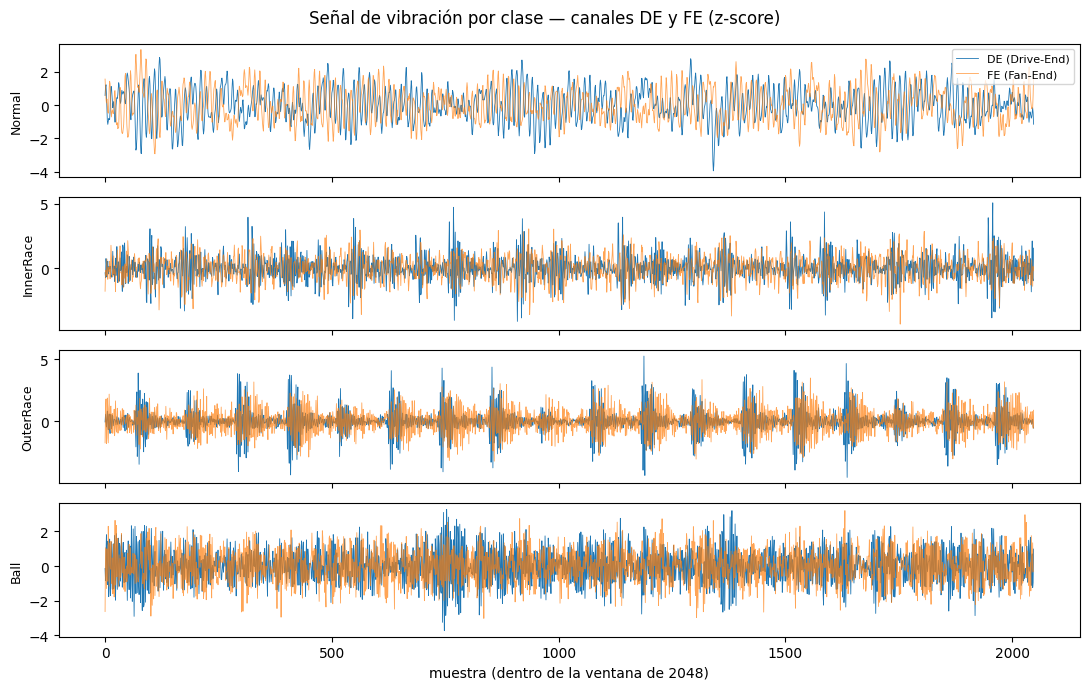

In [5]:
fig, axes = plt.subplots(CFG["n_classes"], 1, figsize=(11, 7), sharex=True)
for cls in range(CFG["n_classes"]):
    i = np.where(y == cls)[0][0]
    ax = axes[cls]
    ax.plot(X[i, 0], lw=0.6, label="DE (Drive-End)")
    ax.plot(X[i, 1], lw=0.6, alpha=0.7, label="FE (Fan-End)")
    ax.set_ylabel(CLASES[cls], fontsize=9)
    if cls == 0:
        ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("muestra (dentro de la ventana de 2048)")
fig.suptitle("Señal de vibración por clase — canales DE y FE (z-score)")
fig.tight_layout()
plt.show()

## 2 · Partición non-IID en "plantas" (Dirichlet)

Separamos un conjunto de **test global** (evaluación del modelo agregado) y repartimos el resto
entre `n_clients` plantas con un reparto **Dirichlet(α)**. Un α pequeño hace que cada planta vea
una mezcla de clases muy distinta (escenario realista: distintas fábricas con distintos perfiles
de falla).

In [6]:
from data.partition import dirichlet_partition, partition_report

# split train/test global (aleatorio reproducible)
rng = np.random.default_rng(CFG["seed"])
perm = rng.permutation(len(y))
n_test = int(CFG["test_frac"] * len(y))
test_idx, train_idx = perm[:n_test], perm[n_test:]
X_tr, y_tr = X[train_idx], y[train_idx]
X_te, y_te = X[test_idx], y[test_idx]
print(f"train: {len(y_tr)}  |  test: {len(y_te)}")

# partición non-IID
parts = dirichlet_partition(y_tr, n_clients=CFG["n_clients"], alpha=CFG["alpha"],
                            seed=CFG["seed"], min_size=8)
client_data = [(X_tr[idx], y_tr[idx]) for idx in parts]
table = partition_report(parts, y_tr, n_classes=CFG["n_classes"])
print("Muestras por cliente:", [len(p) for p in parts])

train: 1230  |  test: 307
Muestras por cliente: [49, 101, 469, 259, 352]


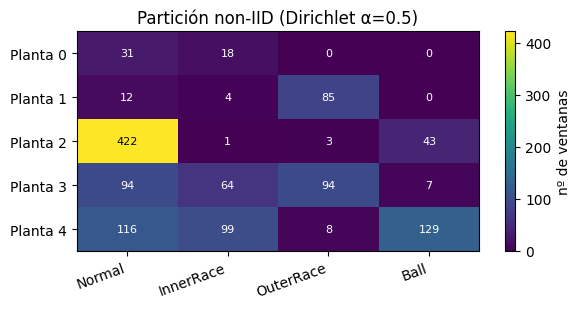

In [7]:
# heatmap de la partición (cliente x clase)
fig, ax = plt.subplots(figsize=(6, 3.2))
im = ax.imshow(table, cmap="viridis", aspect="auto")
ax.set_xticks(range(CFG["n_classes"]))
ax.set_xticklabels([CLASES[c] for c in range(CFG["n_classes"])], rotation=20, ha="right")
ax.set_yticks(range(CFG["n_clients"]))
ax.set_yticklabels([f"Planta {i}" for i in range(CFG["n_clients"])])
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j, i, table[i, j], ha="center", va="center",
                color="w" if table[i, j] < table.max()*0.6 else "k", fontsize=8)
ax.set_title(f"Partición non-IID (Dirichlet α={CFG['alpha']})")
fig.colorbar(im, ax=ax, label="nº de ventanas")
fig.tight_layout()
plt.show()

## 3 · 1D-CNN (WDCNN) + FedAvg — baseline limpio (S0)

Modelo base **WDCNN**: primera convolución de kernel ancho (64, stride 16) sobre la señal cruda de
2 canales, seguida de bloques convolucionales estrechos. Entrenamos con un **loop FL propio**
(FedAvg) sobre las plantas, **sin ataques ni defensas** → este es el techo de desempeño honesto
(escenario **S0**) contra el que luego mediremos la degradación por los adversarios.

In [8]:
from models.cnn1d import build_model

m = build_model(in_channels=len(CFG["channels"]), n_classes=CFG["n_classes"])
n_params = sum(p.numel() for p in m.parameters())
print(m)
print(f"\\nParámetros entrenables: {n_params:,}")

WDCNN(
  (features): Sequential(
    (0): Conv1d(2, 16, kernel_size=(64,), stride=(16,), padding=(24,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [9]:
from federated.fedavg import run_fl

set_seed(CFG["seed"])
global_model, history = run_fl(
    model_fn=lambda: build_model(len(CFG["channels"]), CFG["n_classes"]),
    client_data=client_data,
    test_data=(X_te, y_te),
    rounds=CFG["rounds"], local_epochs=CFG["local_epochs"], lr=CFG["lr"],
    batch_size=CFG["batch_size"], client_frac=CFG["client_frac"],
    device=DEVICE, seed=CFG["seed"], n_classes=CFG["n_classes"], verbose=True,
)
print(f"\\nAccuracy final (S0): {history[-1]['acc']:.4f}")

  ronda  1/20  acc=0.4463


  ronda  2/20  acc=0.6840


  ronda  3/20  acc=0.8795


  ronda  4/20  acc=0.9967


  ronda  5/20  acc=1.0000


...

  ronda 16/20  acc=1.0000


  ronda 17/20  acc=1.0000


  ronda 18/20  acc=1.0000


  ronda 19/20  acc=1.0000


  ronda 20/20  acc=1.0000
\nAccuracy final (S0): 1.0000


Curva de convergencia y matriz de confusión final del modelo global limpio.

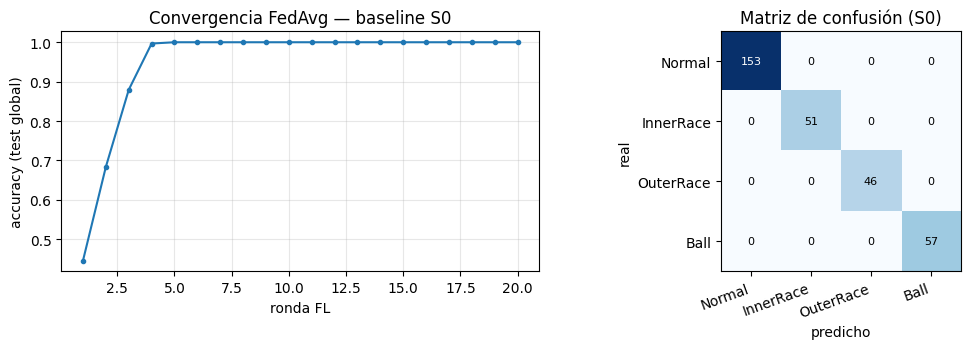

Recall por clase: {'Normal': 1.0, 'InnerRace': 1.0, 'OuterRace': 1.0, 'Ball': 1.0}


In [10]:
from federated.fedavg import make_loader, evaluate

# curva de accuracy
accs = [h["acc"] for h in history]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(range(1, len(accs)+1), accs, marker="o", ms=3)
a1.set_xlabel("ronda FL"); a1.set_ylabel("accuracy (test global)")
a1.set_title("Convergencia FedAvg — baseline S0"); a1.grid(alpha=0.3)

# matriz de confusión
ev = evaluate(global_model, make_loader(X_te, y_te, shuffle=False), DEVICE, n_classes=CFG["n_classes"])
cm = ev["cm"]
im = a2.imshow(cm, cmap="Blues")
a2.set_xticks(range(CFG["n_classes"])); a2.set_yticks(range(CFG["n_classes"]))
labels = [CLASES[c] for c in range(CFG["n_classes"])]
a2.set_xticklabels(labels, rotation=20, ha="right"); a2.set_yticklabels(labels)
a2.set_xlabel("predicho"); a2.set_ylabel("real"); a2.set_title("Matriz de confusión (S0)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        a2.text(j, i, cm[i, j], ha="center", va="center",
                color="w" if cm[i, j] > cm.max()*0.5 else "k", fontsize=8)
fig.tight_layout()
plt.show()
print("Recall por clase:", {CLASES[c]: round(float(r), 3) for c, r in enumerate(ev["recall"])})

Guardamos los resultados del baseline (historia + configuración) para reproducibilidad y para
compararlos después contra los escenarios con ataque.

In [11]:
baseline_out = {
    "config": CFG,
    "n_params": int(n_params),
    "device": DEVICE,
    "history": history,
    "final_acc": history[-1]["acc"],
    "final_recall": {CLASES[c]: float(r) for c, r in enumerate(ev["recall"])},
    "confusion_matrix": cm.tolist(),
}
out_path = os.path.join(RESULTS_DIR, "F1_baseline_S0.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(baseline_out, f, indent=2, ensure_ascii=False)
print("Resultados guardados en:", out_path)

Resultados guardados en: C:\TemaRazielTesis\nuevo enfoque V2\experimento_V2\results\F1_baseline_S0.json


---
### ✅ Estado tras este notebook
- **F0 cerrado:** entorno, descarga automática de CWRU (16 archivos, DE+FE verificados), cargador validado.
- **F1 funcionando:** partición non-IID + 1D-CNN + FedAvg → baseline limpio S0 con su accuracy/recall.

### ▶️ Siguiente (F2–F3)
- **F2:** añadir agregaciones robustas como baselines del Mecanismo 2 — **AutoGM** (Li 2021) y
  **D-WFA** (Chen 2022) — intercambiando el parámetro `aggregate` de `run_fl`.
- **F3:** implementar los ataques en `attacks/` — **Adv1 (FDI al sensor)**, **Adv2 (model/data poisoning)**
  y el **dual coordinado (S3)** — e inyectarlos en `local_train` / la agregación.